# ***1 практика*** / Байкалов Сергей Андреевич / 925-М

Задание 1. Анализ выбросов
Постройте ящики с усами (boxplots) для каждого признака с разбивкой по видам. Определите, есть ли выбросы у вида Iris virginica по признаку sepal width. Какой процент наблюдений выходит за границы усов?

Ответ: У Iris virginica по sepal width найдено 3 выброса (6.0%)

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

  species  
0  setosa  
1  setosa  
2  setosa  
3  setosa  
4  setosa  


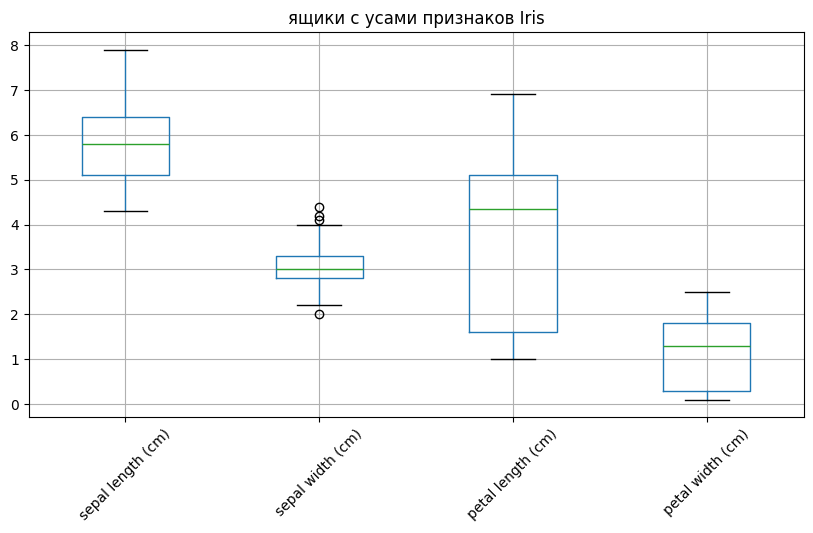

Процент выбросов: 6.0


In [3]:
# генератор случайных чисел
import numpy as np
np.random.seed(42)

# датасет iris
from sklearn.datasets import load_iris

# pandas для работы с таблицами
import pandas as pd

# matplotlib для построения графиков
import matplotlib.pyplot as plt

# датасет iris
iris = load_iris()

# таблица из признаков датасета
df = pd.DataFrame(iris.data, columns=iris.feature_names)

# столбец с названиями видов растений
df["species"] = pd.Categorical.from_codes(
    iris.target,
    iris.target_names
)

# вывод строк таблицы
print(df.head())


# ящики с усами для всех числовых признаков

# окно для графика
plt.figure(figsize=(10, 5))

# ящики с усами по всем числовым столбцам
df.drop("species", axis=1).boxplot()

# заголовок
plt.title("ящики с усами признаков Iris")

# поворот подписи по оси x
plt.xticks(rotation=45)

# график
plt.show()


# выбросы для вида virginica

# только строки с видом virginica
virginica = df[df["species"] == "virginica"]

# выбир нужного столбца
data = virginica["sepal width (cm)"]

# первый квартиль
Q1 = data.quantile(0.25)

# третий квартиль
Q3 = data.quantile(0.75)

# межквартильный размах
IQR = Q3 - Q1

# нижняя граница выбросов
lower = Q1 - 1.5 * IQR

# верхняя граница выбросов
upper = Q3 + 1.5 * IQR

# переменная для подсчета выбросов
outliers = 0

# переборка всех значений столбца
for value in data:

    # является ли значение выбросом
    if value < lower or value > upper:
        outliers = outliers + 1

# количество объектов
total = len(data)

# процент выбросов
percent_outliers = outliers / total * 100

#  результат
print("Процент выбросов:", percent_outliers)



Задание 2. Сравнение дисперсий
Рассчитайте коэффициент вариации (стандартное отклонение / среднее × 100%) для каждого признака. Какой признак наиболее изменчив относительно своего среднего значения? Почему это важно для нормализации данных?

Ответ: Наиболее изменчивый признак — petal width (CV = 63.6%).
Признаки с высоким CV имеют большую абсолютную дисперсию.
В алгоритмах, использующих евклидово расстояние, такой признак будет
доминировать над другими, искажая результат.

In [4]:
# рассчёт коэффициента вариации

# удаление столбца
numeric_df = df.drop("species", axis=1)

# средние значения
mean_values = numeric_df.mean()

# тандартные отклонения
std_values = numeric_df.std()

# пустой массив для результатов
cv = {}

# для каждого признака вычисляю коэффициент вариации
for column in numeric_df.columns:

    cv[column] = (
        std_values[column] /
        mean_values[column]
    ) * 100

print("\nКоэффициенты вариации:")

for key in cv:
    print(key, ":", cv[key])



Коэффициенты вариации:
sepal length (cm) : 14.17112597794403
sepal width (cm) : 14.256420135304118
petal length (cm) : 46.97440748428593
petal width (cm) : 63.55511414344186


Задание 3. Создание нового признака
Создайте производный признак «соотношение длины и ширины лепестка» (petal_length / petal_width). Постройте гистограмму этого признака по видам. Улучшает ли он разделение классов по сравнению с исходными признаками?

Ответ: признак petal_ratio хорошо отделяет Setosa от остальных,
но не улучшает разделение Versicolor и Virginica — их распределения сильно перекрываются.
По коэффициенту разделения, petal_length лучше справляется с разделением всех трёх пар.

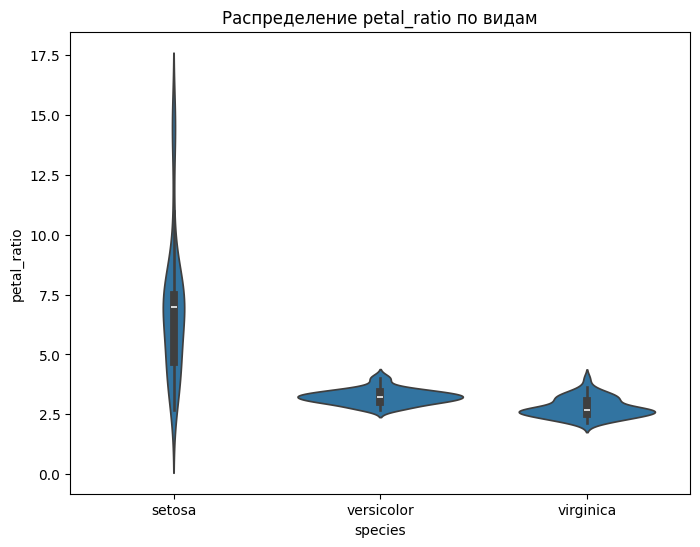

In [10]:
# новый признак как отношение длины лепестка к его ширине
df['petal_ratio'] = df['petal length (cm)'] / df['petal width (cm)']

# окно для графика
plt.figure(figsize=(8, 6))

# violin plot для сравнения распределения petal_ratio у разных видов
sns.violinplot(x='species', y='petal_ratio', data=df)

# заголовок графика
plt.title('Распределение petal_ratio по видам')

# график
plt.show()